# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


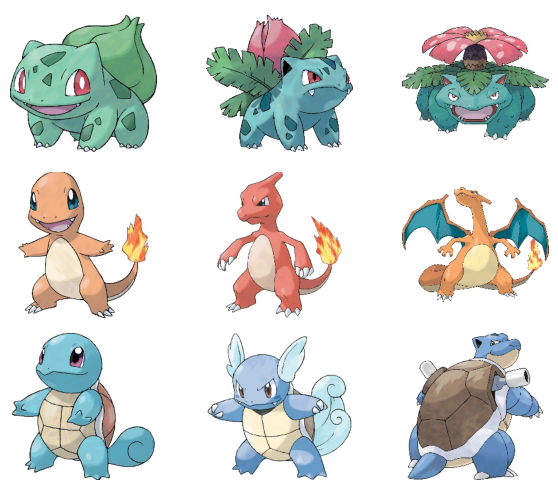

In [55]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [56]:
image, label, name, attributes = dataset[3]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(6),
 'Charmander',
 tensor([ 0.6000,  8.5000, 39.0000, 52.0000, 43.0000, 65.0000]))

Se puede obtener el nombre de la clase con:

In [57]:
dataset.categories[label]

'Fire'

Y los atributos disponibles son:

In [58]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [59]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [60]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus decisiones de diseño.

Antes de implementar el modelo para resolver el problema, tenemos que saber exactamente de qué tamaño son las imágenes (saber cuantos pixeles de alto y ancho tienen).

In [61]:
from pokemon_utils import PokemonImages

dataset_prueba = PokemonImages(data_path='data')

imagen_tensor, etiqueta, nombre, atributos = dataset_prueba[0]

print(f"Pokémon: {nombre}")
print(f"Dimensiones del tensor (Canales, Alto, Ancho): {imagen_tensor.shape}")

Pokémon: Bulbasaur
Dimensiones del tensor (Canales, Alto, Ancho): torch.Size([3, 256, 256])


Calcularemos el número para la variable *dimensiones_imagen_plana* de nuestro modelo:
- Los resultados arrojaron que tenemos un Alto x Ancho de 256 x 256
- Se aplicara una división por 4
- Finalmente se aplica la formula 32 * (Alto final) * (Ancho final)

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha  # Tensor con los pesos suavizados para cada clase
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # ce_loss aplica la entropía cruzada usando los pesos alpha
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        
        # pt es la probabilidad de acierto del modelo
        pt = torch.exp(-ce_loss)
        
        # Fórmula de Focal Loss ponderada por clase
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonMultiModal(nn.Module):
    def __init__(self, num_atributos_numericos, num_clases):
        super().__init__()
        
        self.cnn = nn.Sequential(
        # Bloque 1 (256x256 -> 128x128)
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=4, num_channels=16),  # en vez de nn.BatchNorm2d(16)        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # Bloque 2 (128x128 -> 64x64)
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=8, num_channels=32),  # en vez de nn.BatchNorm2d(16)        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # Bloque 3 (64x64 -> 32x32)
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=8, num_channels=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # Bloque 4 (32x32 -> 16x16)
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.GroupNorm(num_groups=8, num_channels=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        # --- CORRECCIÓN CLAVE: Global Average Pooling ---
        # Esto convierte el bloque de 64x16x16 a simplemente 64 valores (1 por canal)
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten() 
        )
        
        # Ojo: Asegúrate de tener definido el mlp y clasificador_final
        # Ejemplo si los tienes:
        self.mlp = nn.Sequential(
            nn.Linear(num_atributos_numericos, 16),
            nn.ReLU()
        )
        
        # Ahora la fusión es mucho más pequeña: 64 (de la CNN) + 16 (del MLP) = 80
        self.clasificador_final = nn.Sequential(
            nn.Dropout(p=0.4), # <-- Agregar DROPOUT para evitar sobreajuste
            nn.Linear(80, 32),
            nn.ReLU(),
            nn.Dropout(p=0.4), # <-- Agregar DROPOUT
            nn.Linear(32, num_clases)
        )

        # Ahora la imagen aplanada será mucho más manejable: 64 * 16 * 16 = 16,384
        nn.Flatten()


    def forward(self, imagen, atributos):
        # 1. Pasar la imagen por la CNN
        caracteristicas_visuales = self.cnn(imagen)
        
        # 2. Pasar los números por el MLP
        caracteristicas_numericas = self.mlp(atributos)
        
        # 3. Juntar ambas ramas (concatenar a lo largo de la dimensión 1)
        fusion = torch.cat((caracteristicas_visuales, caracteristicas_numericas), dim=1)
        
        # 4. Decisión final
        salida = self.clasificador_final(fusion)
        return salida

In [64]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# 1. Usamos los datasets oficiales 
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 2. Solución al Desbalance: Calcular pesos por clase
# Extraemos todas las etiquetas de entrenamiento para contar cuántas hay de cada tipo
etiquetas_train = [train_dataset[i][1] for i in range(len(train_dataset))]
conteo_clases = np.bincount(etiquetas_train, minlength=(len(dataset.categories)))
print("número de clases:", len(dataset.categories))

# --- CORRECCIÓN: Suavizado con raíz cuadrada para evitar sesgo extremo ---
pesos_clases = 1.0 / (np.sqrt(conteo_clases) + 1e-5)
pesos_clases = pesos_clases / np.mean(pesos_clases)
pesos_tensor = torch.tensor(pesos_clases, dtype=torch.float32)

# 3. Solución a las escalas: Calcular Media y Desviación para Normalizar
# Extraemos los atributos numéricos para saber su escala real
atributos_train = torch.stack([train_dataset[i][3] for i in range(len(train_dataset))])
atr_mean = atributos_train.mean(dim=0)
atr_std = atributos_train.std(dim=0)

print("DataLoaders listos con el split oficial.")
print("Pesos para la pérdida calculados (para combatir el desbalance).")
print("Estadísticas de normalización calculadas.")


número de clases: 18
DataLoaders listos con el split oficial.
Pesos para la pérdida calculados (para combatir el desbalance).
Estadísticas de normalización calculadas.


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

**Elección y justificación de Hiperparámetros y Diseño de Entrenamiento:**

* **Función de Pérdida (`CrossEntropyLoss` con pesos):** Al ser un problema de clasificación multiclase (18 tipos elementales), esta es la función matemática estándar. Sin embargo, para atacar el principal desafío de la tarea (el desbalance de clases), calculamos la frecuencia inversa de cada tipo de Pokémon en el set de entrenamiento y se lo pasamos como parámetro `weight`. Esto hace que la red reciba una penalización mucho mayor si se equivoca en una clase minoritaria (ej. Hielo) que en una mayoritaria (ej. Agua).
* **Normalización Tabular (Prevención de Data Leakage):** Los 6 atributos numéricos tienen escalas muy distintas (ej. Stats de 200 vs Alturas de 1.5m). Para estabilizar el aprendizaje de la rama MLP, estandarizamos estos datos restando la media y dividiendo por la desviación estándar. Es vital destacar que estos valores estadísticos se calcularon **exclusivamente con el set de entrenamiento**, y esos mismos valores se aplicaron al set de prueba para evitar "fuga de datos" (que el modelo adquiera información del set de evaluación antes de tiempo).
* **Optimizador (`Adam`, lr=0.001):** Ideal para arquitecturas multimodales porque adapta dinámicamente la tasa de aprendizaje para cada peso de la red, evitando estancamientos. El *Learning Rate* de 0.001 es un inicio conservador y estable.


In [65]:
# import os
# import subprocess
# import getpass

# class ModoProCPU:
#     def __init__(self):
#         self.pwd = getpass.getpass(prompt='Contraseña sudo: ')
#         # Obtenemos el ID del proceso exacto de este notebook
#         self.pid = os.getpid() 

#     def __enter__(self):
#         print("🔥 Activando fuerza bruta: Frecuencia máxima y Prioridad Extrema...")
        
#         # 1. Forzar gobernador de CPU a máximo rendimiento
#         cmd_cpu = f"echo {self.pwd} | sudo -S cpupower frequency-set -g performance"
#         subprocess.run(cmd_cpu, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        
#         # 2. Asignar prioridad máxima (-20) a este kernel de Jupyter
#         cmd_renice = f"echo {self.pwd} | sudo -S renice -n -20 -p {self.pid}"
#         subprocess.run(cmd_renice, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        
#         return self

#     def __exit__(self, exc_type, exc_value, traceback):
#         print("❄️ Finalizado. Restaurando con TLP y prioridad normal...")
        
#         # 1. Usar TLP para restaurar el ahorro de energía en todo el sistema
#         cmd_tlp = f"echo {self.pwd} | sudo -S tlp power-saver"
#         subprocess.run(cmd_tlp, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        
#         # 2. Devolver este notebook a la prioridad normal (0)
#         cmd_renice_normal = f"echo {self.pwd} | sudo -S renice -n 0 -p {self.pid}"
#         subprocess.run(cmd_renice_normal, shell=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
torch.set_num_threads(4)
device = torch.device("cpu")
# 1. Instanciamos el modelo multimodal
modelo_final = PokemonMultiModal(
    num_atributos_numericos=6, 
    num_clases=len(dataset.categories)
).to(device=device, memory_format=torch.channels_last)

# 2. Configuramos la pérdida con WeightedFocalLoss y los pesos suavizados
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)

optimizador = optim.Adam(modelo_final.parameters(), lr=0.0005, weight_decay=1e-4)
epocas = 30

loss_historial = []
atr_mean = atr_mean.to(device)
atr_std = atr_std.to(device)

print(f"Iniciando entrenamiento BASE por {epocas} épocas...")

for epoca in range(epocas):
    modelo_final.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas, nombres, atributos in train_loader:
        imagenes = imagenes.to(device=device, memory_format=torch.channels_last)
        etiquetas = etiquetas.to(device)
        atributos = atributos.to(device)
        
        # Restamos la media y dividimos por la desviación estándar
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        optimizador.zero_grad()
        
        # Usamos los atributos normalizados
        predicciones = modelo_final(imagenes, atributos_normalizados)
        loss = criterio(predicciones, etiquetas)
        
        loss.backward()
        optimizador.step()
        
        loss_acumulada += loss.item()
        
    loss_promedio = loss_acumulada / len(train_loader)
    loss_historial.append(loss_promedio)
    
    if (epoca + 1) % 5 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss: {loss_promedio:.4f}")
        
print("¡Entrenamiento finalizado!")


/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/torch/cuda/__init__.py:384: UserWarning: Found GPU0 NVIDIA GeForce MX130 which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/torch/cuda/__init__.py:502: UserWarning: 
NVIDIA GeForce MX130 with CUDA capability sm_50 is not compatible with the current PyTorch

AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


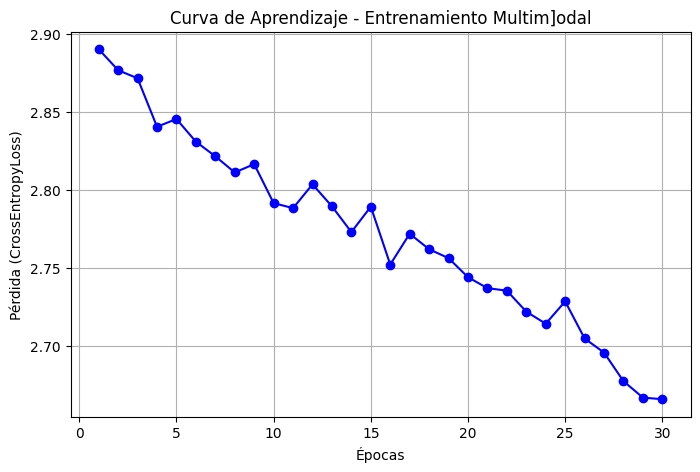

In [52]:
import matplotlib.pyplot as plt

# Generar la Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(1, epocas + 1), loss_historial, marker='o', linestyle='-', color='b')
plt.title("Curva de Aprendizaje - Entrenamiento Multim]odal")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.grid(True)
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

         Bug       0.00      0.00      0.00         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.00      0.00      0.00         5
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.00      0.00      0.00         5
       Ghost       0.00      0.00      0.00         3
       Grass       0.06      0.11      0.07         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.38      0.83      0.53        12
      Poison       0.00      0.00      0.00         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.22      0.40      0.29         5
       Steel       0.00      0.00      0.00         2
       Water       0.17      0.36      0.23     

/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

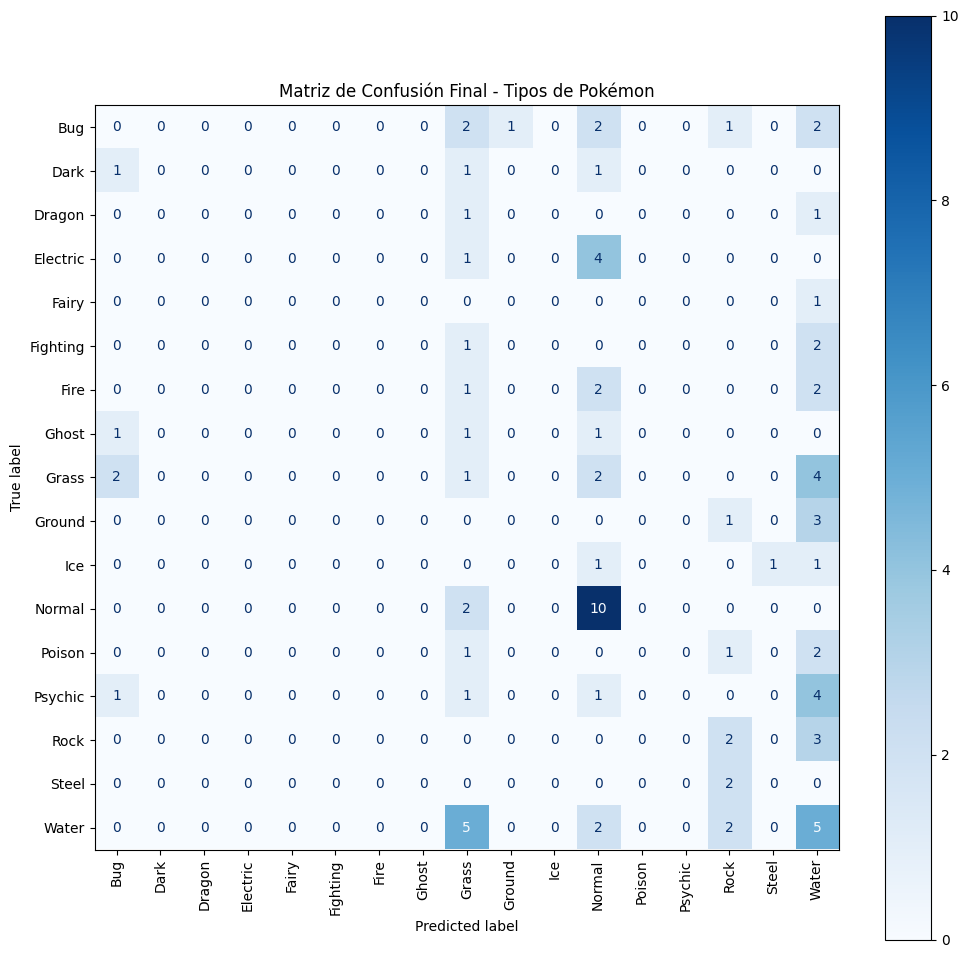

In [53]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# ==========================================
# EVALUACIÓN DEL MODELO Y RECOLECCIÓN DE PREDICCIONES
# ==========================================
modelo_final.eval() # Ponemos el modelo en modo evaluación (desactiva Dropout/BatchNorm)
y_real = []
y_pred = []

# No necesitamos calcular gradientes en la evaluación
with torch.no_grad():
    for imagenes, etiquetas, nombres, atributos in test_loader:
        imagenes = imagenes.to(device)
        
        # Mismo procedimiento de normalización que usamos en el entrenamiento
        atributos = atributos.to(device)
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        # Hacemos la predicción
        salidas = modelo_final(imagenes, atributos_normalizados)
        
        # Nos quedamos con la clase que tenga mayor probabilidad
        _, predicciones = torch.max(salidas, 1)
        
        # Guardamos las verdaderas y las predichas en nuestras listas
        y_real.extend(etiquetas.cpu().numpy())
        y_pred.extend(predicciones.cpu().numpy())
# ==========================================

# Generar el reporte de clasificación usando las categorías de tu dataset
# Solo le pasamos las etiquetas únicas que realmente se predijeron o existían en y_real/y_pred
etiquetas_presentes = sorted(list(set(y_real).union(set(y_pred))))
nombres_etiquetas = [dataset.categories[i] for i in etiquetas_presentes]

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real, y_pred, labels=etiquetas_presentes, target_names=nombres_etiquetas))

# Generar la Matriz de Confusión Visual
cm = confusion_matrix(y_real, y_pred, labels=etiquetas_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_etiquetas)

fig, ax = plt.subplots(figsize=(12, 12)) # Agrandamos la figura porque son muchas clases
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusión Final - Tipos de Pokémon")
plt.show()


### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

Total de errores en el Test Set: 72 de 90


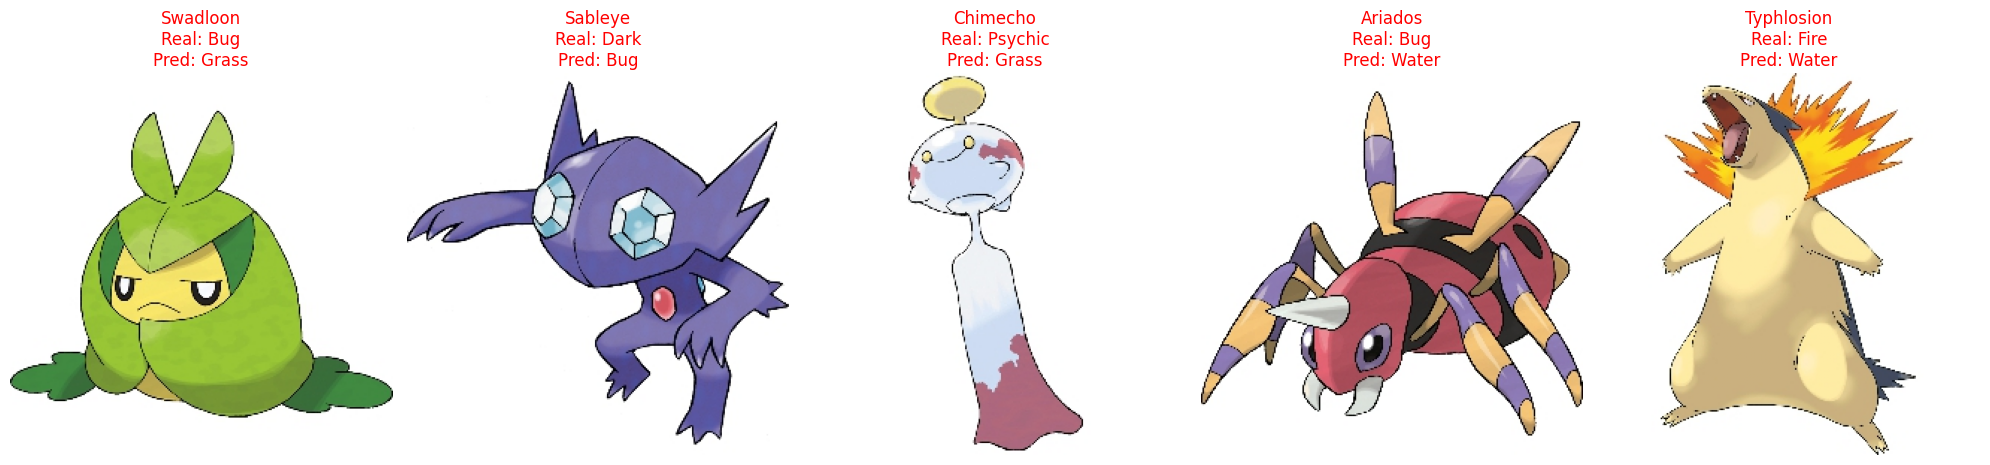

In [54]:
import numpy as np

# 1. Encontrar los índices donde el modelo falló
errores_idx = np.where(np.array(y_real) != np.array(y_pred))[0]
print(f"Total de errores en el Test Set: {len(errores_idx)} de {len(y_real)}")

# 2. Visualizar los primeros 5 ejemplos mal clasificados
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, idx in enumerate(errores_idx[:5]): 
    # Extraer los datos originales del test_dataset
    imagen_tensor, etiqueta_real, nombre, atributos = test_dataset[idx]
    prediccion = y_pred[idx]
    
    # Obtener el texto del tipo real y el predicho
    tipo_real = dataset.categories[etiqueta_real]
    tipo_predicho = dataset.categories[prediccion]
    
    # Las imágenes en PyTorch tienen shape (Canales, Alto, Ancho)
    # plt.imshow espera (Alto, Ancho, Canales), por lo que usamos permute()
    img_mostrar = imagen_tensor.permute(-2, -1, 0).cpu().numpy()
    
    # Si usaste alguna normalización con media y desviación estándar, 
    # la imagen puede verse con colores raros, pero es normal.
    axes[i].imshow(img_mostrar)
    axes[i].set_title(f"{nombre}\nReal: {tipo_real}\nPred: {tipo_predicho}", fontsize=12, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.

In [35]:
import torchvision.transforms as T

train_transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.RandomResizedCrop(size=(256, 256), scale=(0.95, 1.0)),
])

class AugmentedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label, name, attributes = self.subset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label, name, attributes

train_dataset_aug = AugmentedSubset(train_dataset, transform=train_transforms)
train_loader = DataLoader(train_dataset_aug, batch_size=16, shuffle=True)

In [36]:
import torch
import torch.optim as optim
import torch.nn as nn
torch.set_num_threads(4)
device = torch.device("cpu")

# 1. Instanciamos el modelo multimodal
modelo_final = PokemonMultiModal(
    num_atributos_numericos=6, 
    num_clases=len(dataset.categories)
).to(device=device, memory_format=torch.channels_last)

# 2. Configuramos la pérdida con WeightedFocalLoss y los pesos suavizados
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)
optimizador = optim.Adam(modelo_final.parameters(), lr=0.0005, weight_decay=1e-4)
epocas = 30

loss_historial = []
atr_mean = atr_mean.to(device)
atr_std = atr_std.to(device)

print(f"Iniciando entrenamiento BASE por {epocas} épocas...")

for epoca in range(epocas):
    modelo_final.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas, nombres, atributos in train_loader:
        imagenes = imagenes.to(device=device, memory_format=torch.channels_last)
        etiquetas = etiquetas.to(device)
        atributos = atributos.to(device)
        
        # Restamos la media y dividimos por la desviación estándar
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        optimizador.zero_grad()
        
        # Usamos los atributos normalizados
        predicciones = modelo_final(imagenes, atributos_normalizados)
        loss = criterio(predicciones, etiquetas)
        
        loss.backward()
        optimizador.step()
        
        loss_acumulada += loss.item()
        
    loss_promedio = loss_acumulada / len(train_loader)
    loss_historial.append(loss_promedio)
    
    if (epoca + 1) % 5 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss: {loss_promedio:.4f}")
        
print("¡Entrenamiento finalizado!")


Iniciando entrenamiento BASE por 30 épocas...
Época [5/30] | Loss: 2.7362
Época [10/30] | Loss: 2.5827
Época [15/30] | Loss: 2.4832
Época [20/30] | Loss: 2.4333
Época [25/30] | Loss: 2.4165
Época [30/30] | Loss: 2.3384
¡Entrenamiento finalizado!


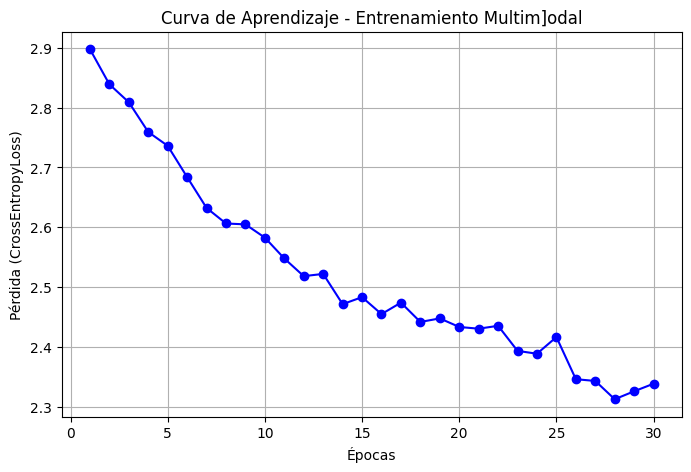

In [37]:
import matplotlib.pyplot as plt

# Generar la Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(1, epocas + 1), loss_historial, marker='o', linestyle='-', color='b')
plt.title("Curva de Aprendizaje - Entrenamiento Multim]odal")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.grid(True)
plt.show()

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

         Bug       0.17      0.12      0.14         8
        Dark       0.00      0.00      0.00         3
      Dragon       0.00      0.00      0.00         2
    Electric       0.00      0.00      0.00         5
       Fairy       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         3
        Fire       0.29      0.80      0.42         5
       Ghost       0.50      0.33      0.40         3
       Grass       0.58      0.78      0.67         9
      Ground       0.00      0.00      0.00         4
         Ice       0.00      0.00      0.00         3
      Normal       0.29      0.42      0.34        12
      Poison       0.29      0.50      0.36         4
     Psychic       0.00      0.00      0.00         7
        Rock       0.50      0.20      0.29         5
       Steel       0.00      0.00      0.00         2
       Water       0.32      0.57      0.41     

/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jonagu/Desktop/Cursos/IA/.venv_ia/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

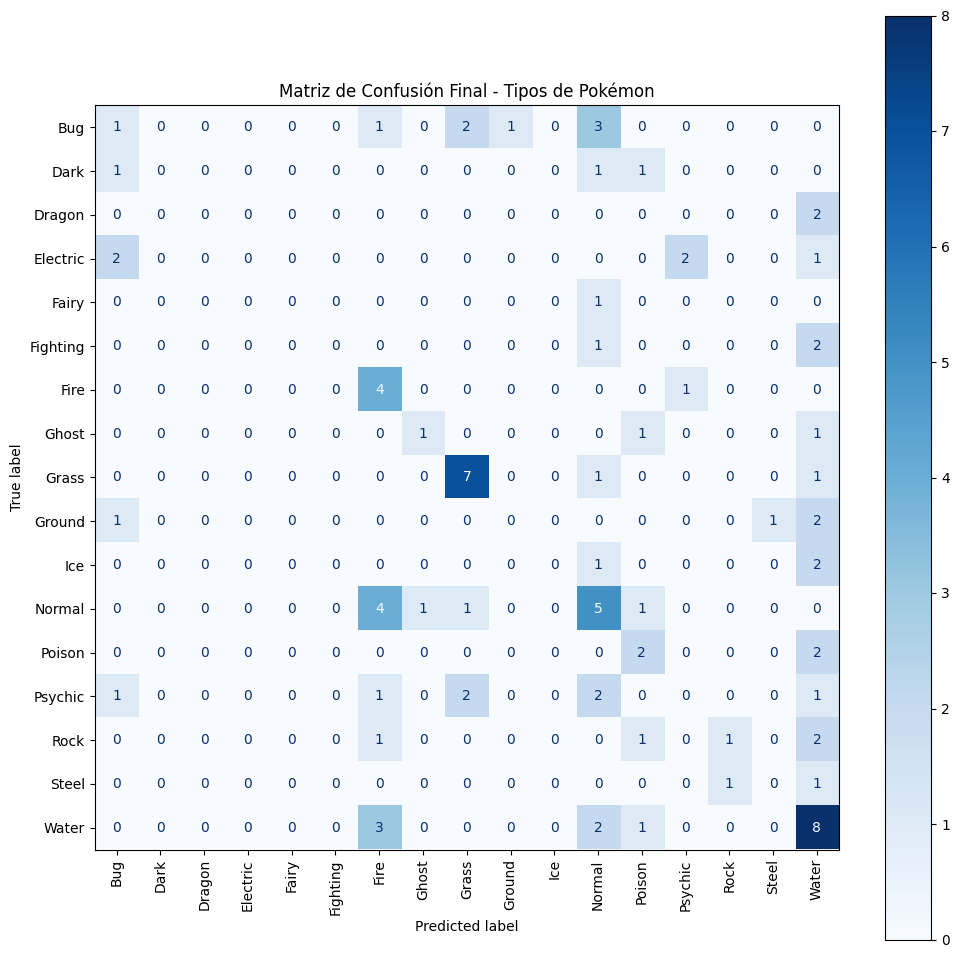

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# ==========================================
# EVALUACIÓN DEL MODELO Y RECOLECCIÓN DE PREDICCIONES
# ==========================================
modelo_final.eval() # Ponemos el modelo en modo evaluación (desactiva Dropout/BatchNorm)
y_real = []
y_pred = []

# No necesitamos calcular gradientes en la evaluación
with torch.no_grad():
    for imagenes, etiquetas, nombres, atributos in test_loader:
        imagenes = imagenes.to(device)
        
        # Mismo procedimiento de normalización que usamos en el entrenamiento
        atributos = atributos.to(device)
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        # Hacemos la predicción
        salidas = modelo_final(imagenes, atributos_normalizados)
        
        # Nos quedamos con la clase que tenga mayor probabilidad
        _, predicciones = torch.max(salidas, 1)
        
        # Guardamos las verdaderas y las predichas en nuestras listas
        y_real.extend(etiquetas.cpu().numpy())
        y_pred.extend(predicciones.cpu().numpy())
# ==========================================

# Generar el reporte de clasificación usando las categorías de tu dataset
# Solo le pasamos las etiquetas únicas que realmente se predijeron o existían en y_real/y_pred
etiquetas_presentes = sorted(list(set(y_real).union(set(y_pred))))
nombres_etiquetas = [dataset.categories[i] for i in etiquetas_presentes]

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real, y_pred, labels=etiquetas_presentes, target_names=nombres_etiquetas))

# Generar la Matriz de Confusión Visual
cm = confusion_matrix(y_real, y_pred, labels=etiquetas_presentes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_etiquetas)

fig, ax = plt.subplots(figsize=(12, 12)) # Agrandamos la figura porque son muchas clases
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusión Final - Tipos de Pokémon")
plt.show()


Total de errores en el Test Set: 61 de 90


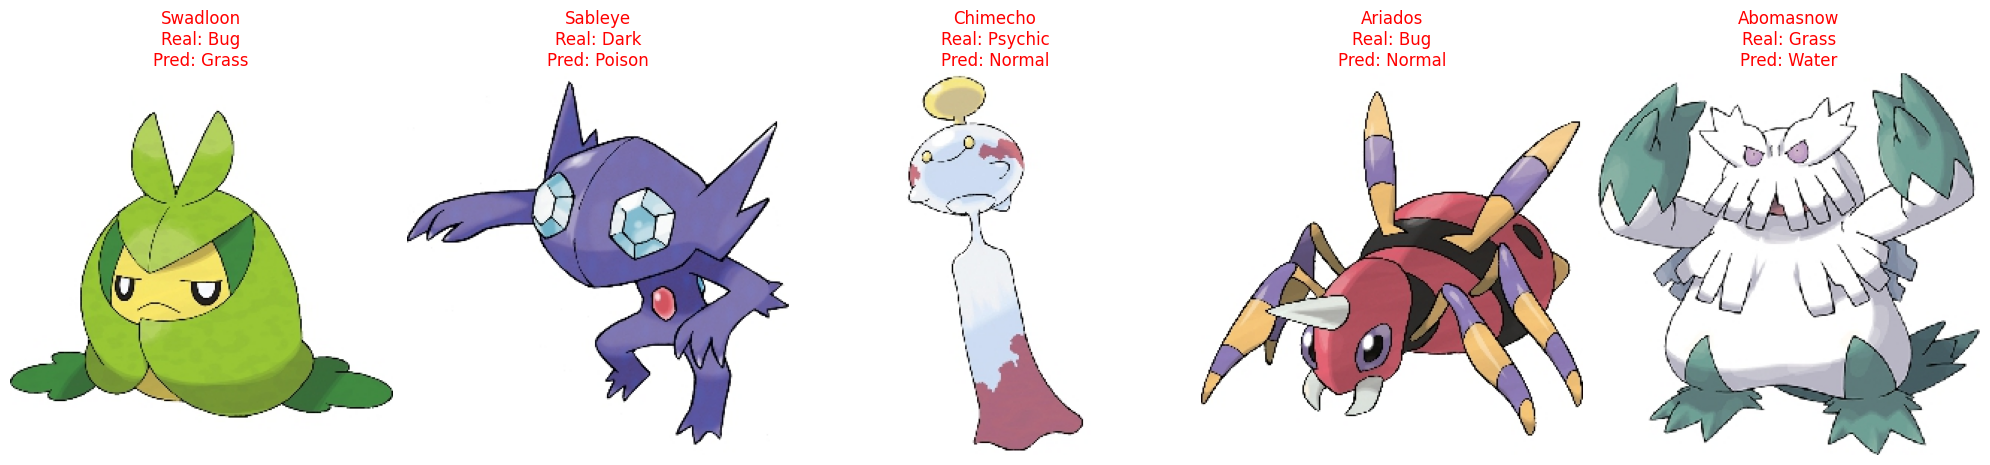

In [39]:
import numpy as np

# 1. Encontrar los índices donde el modelo falló
errores_idx = np.where(np.array(y_real) != np.array(y_pred))[0]
print(f"Total de errores en el Test Set: {len(errores_idx)} de {len(y_real)}")

# 2. Visualizar los primeros 5 ejemplos mal clasificados
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, idx in enumerate(errores_idx[:5]): 
    # Extraer los datos originales del test_dataset
    imagen_tensor, etiqueta_real, nombre, atributos = test_dataset[idx]
    prediccion = y_pred[idx]
    
    # Obtener el texto del tipo real y el predicho
    tipo_real = dataset.categories[etiqueta_real]
    tipo_predicho = dataset.categories[prediccion]
    
    # Las imágenes en PyTorch tienen shape (Canales, Alto, Ancho)
    # plt.imshow espera (Alto, Ancho, Canales), por lo que usamos permute()
    img_mostrar = imagen_tensor.permute(-2, -1, 0).cpu().numpy()
    
    # Si usaste alguna normalización con media y desviación estándar, 
    # la imagen puede verse con colores raros, pero es normal.
    axes[i].imshow(img_mostrar)
    axes[i].set_title(f"{nombre}\nReal: {tipo_real}\nPred: {tipo_predicho}", fontsize=12, color='red')
    axes[i].axis('off')

plt.tight_layout()
plt.show()
